In [ ]:
pip install scikit-learn


In [ ]:
pip install sympy


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import nltk
from nltk.corpus import stopwords
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
# Descargar las stopwords en español
nltk.download('stopwords')

# Definir stopwords y agregar palabras adicionales
stop_words = set(stopwords.words('spanish'))
stop_words.update({"q", "xd", "aja", "jaja", "jajaja", "ja", "xq", "k"})

# Cargar modelo de lenguaje en español de spaCy
nlp = spacy.load("es_core_news_sm")

# Función para limpiar texto
def limpiar_texto(texto):
    # Normalizar caracteres especiales (tildes, acentos, etc.)
    texto = unicodedata.normalize('NFD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = texto.lower()  # Convertir a minúsculas
    texto = re.sub(r"@\w+|https?://\S+", "", texto)  # Eliminar menciones y enlaces
    texto = re.sub(r"#", "", texto)  # Eliminar hashtags
    texto = re.sub(r'(.)\1{2,}', r'\1', texto)  # Reducir repeticiones de caracteres
    texto = re.sub(r"[^a-zA-Z0-9\s]", "", texto)  # Eliminar caracteres especiales
    palabras_limpias = [palabra for palabra in texto.split() if palabra not in stop_words]  # Remover stopwords
    return " ".join(palabras_limpias)

# Inicializar listas para datos y etiquetas
datos = []
etiquetas = []

# Leer archivo de tweets
with open('tweets.txt', 'r', encoding='utf-8') as file:
    lines = file.readlines()

# Procesar cada línea del archivo
for line in lines:
    parts = line.strip().split('\t', 1)  # Separar etiqueta y texto del tweet
    if len(parts) < 2:
        continue  # Ignorar líneas mal formateadas
    etiqueta = parts[0].lower()
    texto = parts[1]


    if etiqueta == 'n':
        etiquetas.append(0)  # Negativo
    elif etiqueta == 'p':
        etiquetas.append(1)  # Positivo
    else:
        continue

    datos.append(texto)  # Agregar texto original a la lista

# Aplicar limpieza de texto a todos los tweets
datos_limpiados = [limpiar_texto(texto) for texto in datos]

# Aplicar vectorización TF-IDF con ciertos parámetros
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_df=0.40, ngram_range=(1, 1))

# Convertir datos a matriz TF-IDF
X_tfidf = tfidf_vectorizer.fit_transform(datos_limpiados)

# Imprimir algunos ejemplos de tweets procesados
print("Datos procesados y vectorizados:")
for i in range(min(5, len(datos))):
    print(f"Tweet original: {datos[i]}")
    print(f"Tweet limpio: {datos_limpiados[i]}")
    print(f"Vector TF-IDF: {X_tfidf[i]}")
    print("-" * 5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sebastian\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Datos procesados y vectorizados:
Tweet original: No mames este pinche dolor que pedo? ya mejor llévame Diosito.
Tweet limpio: mames pinche dolor pedo mejor llevame diosito
Vector TF-IDF:   (0, 681)	0.43672927115442245
  (0, 880)	0.3619853267867433
  (0, 363)	0.4765721077118005
  (0, 839)	0.37787242689277334
  (0, 700)	0.2849642928586866
  (0, 352)	0.4765721077118005
-----
Tweet original: @benshorts a juzgar por mis comportamientos autodestructivos en las relaciones, aún quiero serlo
Tweet limpio: juzgar comportamientos autodestructivos relaciones aun quiero serlo
Vector TF-IDF:   (0, 988)	0.6988703277448972
  (0, 89)	0.5841678696355731
  (0, 959)	0.4127083293116048
-----
Tweet original: #BuenosDias mundo Twittero ya desperté y estoy listo para vivir un dia mas #ExcelenteMartes
Tweet limpio: buenosdias mundo twittero desperte listo vivir dia mas excelentemartes
Vector TF-IDF:   (0, 139)	0.43616801539451444
  (0, 748)	0.3242267742491762
  (0, 1172)	0.4181949063926741
  (0, 327)	0.4042538

In [ ]:
# Convertir la matriz TF-IDF a un array denso
X_tfidf = tfidf_vectorizer.fit_transform(datos_limpiados).toarray()

# Convertir las etiquetas a un tensor de tipo float
y = torch.tensor(etiquetas, dtype=torch.float32)

# División de datos en entrenamiento y prueba 80%-20%
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Definir la clase Dataset personalizada
class Dato(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Convertir datos a tensores
        self.y = y  # Las etiquetas ya son tensores

    def __len__(self):
        return len(self.X)  # Número total de muestras

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Crear conjuntos de datos para entrenamiento y prueba
train_dataset = Dato(X_train, y_train)
test_dataset = Dato(X_test, y_test)

# Crear dataloaders para manejar los datos en lotes
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
# Contar el total de positivos y negativos en el conjunto de entrenamiento
total_positivos = (y_train == 1).sum().item()
total_negativos = (y_train == 0).sum().item()

# Imprimir los totales
print("positivos ",total_positivos,"\nnegativos ", total_negativos)


positivos  361 
negativos  588


In [ ]:
# Definir modelo BiLSTM
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(BiLSTM, self).__init__()

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=1, bidirectional=True, batch_first=True)

        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # Multiplicamos por 2 porque es bidireccional
        # Capa de dropout para evitar overfitting
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Añadir una dimensión extra para que LSTM lo procese correctamente
        lstm_out, _ = self.lstm(x)
        final_output = self.fc(lstm_out[:, -1, :])
        return final_output

# Inicializar el modelo con los parámetros adecuados
input_dim = X_tfidf.shape[1]  # Dimensión de entrada = número de características TF-IDF
hidden_dim = 256  # Tamaño de las unidades ocultas en la LSTM
output_dim = 1  # Salida binaria (positivo o negativo)

# Crear la instancia del modelo
model = BiLSTM(input_dim, hidden_dim, output_dim)

Epoch 1, Loss: 25.7194704413414
Epoch 2, Loss: 25.32507222890854
Epoch 3, Loss: 24.652742564678192
Epoch 4, Loss: 23.342989563941956
Epoch 5, Loss: 21.226627469062805
Epoch 6, Loss: 18.54860407114029
Epoch 7, Loss: 15.641890078783035
Epoch 8, Loss: 13.04770341515541
Epoch 9, Loss: 10.927705645561218
Epoch 10, Loss: 9.236099407076836
Epoch 11, Loss: 7.947986513376236
Epoch 12, Loss: 6.838617026805878
Epoch 13, Loss: 5.952772364020348
Epoch 14, Loss: 5.23432283103466
Epoch 15, Loss: 4.665036469697952
Epoch 16, Loss: 4.148451097309589
Epoch 17, Loss: 3.723509758710861
Epoch 18, Loss: 3.3810484036803246
Epoch 19, Loss: 3.183285754173994
Epoch 20, Loss: 2.7629814259707928
Epoch 21, Loss: 2.5186344645917416
Epoch 22, Loss: 2.365605216473341
Epoch 23, Loss: 2.156143246218562
Epoch 24, Loss: 1.976069226861
Epoch 25, Loss: 1.8403481058776379
Epoch 26, Loss: 1.715021550655365
Epoch 27, Loss: 1.6116498298943043
Epoch 28, Loss: 1.5340494588017464
Epoch 29, Loss: 1.4365890882909298
Epoch 30, Loss: 

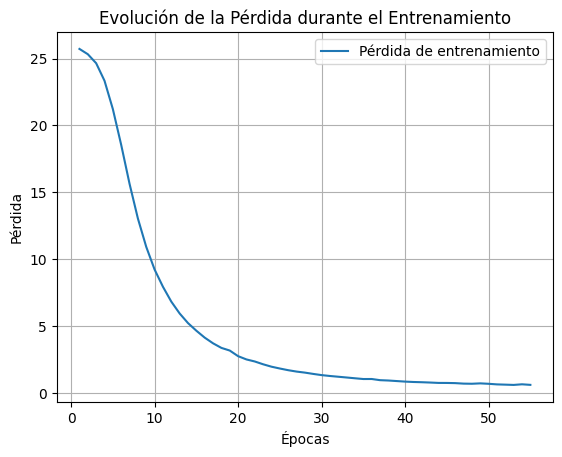

In [ ]:
# Definir el peso como un tensor
pos_weight = torch.tensor([588 / 361])

# Definir la función de pérdida con pesos
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Entrenar modelo
def Entrenamiento(model, train_loader, criterion, optimizer, epochs=55):
    model.train()  # Poner el modelo en modo entrenamiento
    losses = []  # Lista para almacenar la pérdida en cada época

    for epoch in range(epochs):
        total_loss = 0  # Acumulador de la pérdida en la época actual

        for batch in train_loader:
            X_batch, y_batch = batch # Obtener lote de datos
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze() # Hacer predicción con el modelo
            loss = criterion(y_pred, y_batch) # Calcular la pérdida
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss}")

    return losses

# Entrenar y almacenar las pérdidas
losses = Entrenamiento(model, train_loader, criterion, optimizer)

# Graficar la pérdida por época
plt.plot(range(1, 56), losses, label='Pérdida de entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluar modelo
correctos = 0
total = 0
with torch.no_grad():
    model.eval()
    for inputs, labels in test_loader:
        outputs = model(inputs).squeeze()
        predicted = (outputs > 0.5).float()
        correctos += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correctos / total
print(f"Accuracy del modelo: {accuracy * 100:.2f}%")

Accuracy del modelo: 73.11%


In [ ]:
def clasificacion_datos(text):
    encoded = tfidf_vectorizer.transform([limpiar_texto(text)]).toarray()
    tensor_input = torch.tensor(encoded, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        output = model(tensor_input).squeeze().item()  # Obtener la salida del modelo y convertir a número
        print(f"Salida del modelo: {output}")  # Imprimir la salida para depuración

    # Devolver "Positivo" si la salida es mayor a 0.5, de lo contrario "Negativo"
    return "Positivo" if output > 0.5 else "Negativo"

# Pruebas de clasificación
ejemplos = [
     # Negativos (N)
    "No mames este pinche dolor que pedo? ya mejor llévame Diosito.",
    "Puta madre lo que me faltaba enfermarme #QuieroLlorar",
    "Estoy tan cansado de todo, nada me sale bien últimamente.",
    "No soporto más este estrés, todo es un caos en mi vida.",
    "Me despidieron del trabajo, no sé qué voy a hacer ahora.",

    # Positivos (P)
    "Pagaré una maleta extra para todos nuestros nuevos momentos juntos",
    "#BuenosDias mundo Twittero ya desperté y estoy listo para vivir un dia mas #ExcelenteMartes",
    "Hoy fue un día increíble, logré todo lo que me propuse.",
    "Qué felicidad, por fin llegó el fin de semana, a disfrutar!",
    "Amo estos momentos en familia, son lo mejor que tengo.",
]

for ejemplo in ejemplos:
    print(f"Texto: {ejemplo}\nPredicción: {clasificacion_datos(ejemplo)}\n")

Salida del modelo: -5.5755295753479
Texto: No mames este pinche dolor que pedo? ya mejor llévame Diosito.
Predicción: Negativo

Salida del modelo: -9.844483375549316
Texto: Puta madre lo que me faltaba enfermarme #QuieroLlorar
Predicción: Negativo

Salida del modelo: 2.400402784347534
Texto: Estoy tan cansado de todo, nada me sale bien últimamente.
Predicción: Positivo

Salida del modelo: -3.1466684341430664
Texto: No soporto más este estrés, todo es un caos en mi vida.
Predicción: Negativo

Salida del modelo: -3.8364062309265137
Texto: Me despidieron del trabajo, no sé qué voy a hacer ahora.
Predicción: Negativo

Salida del modelo: 5.791959285736084
Texto: Pagaré una maleta extra para todos nuestros nuevos momentos juntos
Predicción: Positivo

Salida del modelo: 7.269259929656982
Texto: #BuenosDias mundo Twittero ya desperté y estoy listo para vivir un dia mas #ExcelenteMartes
Predicción: Positivo

Salida del modelo: 3.7357397079467773
Texto: Hoy fue un día increíble, logré todo lo qu